# Comportamento de LT sem perdas para diferentes valores de carregamento

**Antonio Carlos Siqueira de Lima**  
2026/1

---
## Início

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# Okabe-Ito colorblind-friendly palette
color_blind_palette = [
    (0.902, 0.624, 0.000),   # Orange
    (0.337, 0.706, 0.914),   # Sky Blue
    (0.000, 0.620, 0.451),   # Bluish Green
    (0.941, 0.894, 0.259),   # Yellow
    (0.000, 0.447, 0.698),   # Blue
    (0.835, 0.369, 0.000),   # Vermillion
    (0.800, 0.475, 0.655),   # Reddish Purple
]

# Global matplotlib style settings
plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        14,
    'axes.grid':        True,
    'grid.color':       '#D9D9D9',
    'grid.linestyle':   '--',
    'axes.linewidth':   1.2,
    'figure.figsize':   (7, 14/3),   # ~600px wide, 2/3 aspect
})

### Algumas constantes

In [3]:
mu      = 4.0 * np.pi * 1e-7          # Permeabilidade magnética do vácuo [H/m]
epsilon = 8.854e-12                    # Permissividade elétrica do vácuo [F/m]
ell     = 50.0                         # Comprimento do circuito [km]

# Parâmetros distribuídos por unidade de comprimento (60 Hz)
z = 1j * 0.484                         # Impedância série [Ω/km]
y = 1j * 3.448e-6                      # Admitância shunt [S/km]

gamma = np.sqrt(z * y)                 # Constante de propagação [1/km]
Zc    = np.sqrt(z / y)                 # Impedância característica [Ω]

velocidade = 1e-3 *2 * np.pi * 60.0 / gamma.imag  # Velocidade de propagação [m/µs]

print(f"γ  = {gamma}  [1/km]")
print(f"Zc = {Zc.real:.4f}  [Ω]")
print(f"v  = {velocidade:.2f}  [m/µs]")

γ  = 0.0012918328065194813j  [1/km]
Zc = 374.6615  [Ω]
v  = 291.83  [m/µs]


---
## Definição do Quadripolo (Parâmetros ABCD)

In [4]:
# Elementos da matriz ABCD exata (linha sem perdas)
A = np.cosh(gamma * ell)
B = Zc * np.sinh(gamma * ell)
C = (1.0 / Zc) * np.sinh(gamma * ell)

# Matriz ABCD  [A B; C A]  (linha simétrica → D = A)
Q = np.array([[A, B],
              [C, A]])

print("Matriz ABCD:")
print(f"  A = {A:.6f}")
print(f"  B = {B:.6f}")
print(f"  C = {C:.10f}")
print(f"  det(Q) = {np.linalg.det(Q):.6f}   (deve ser 1.0)")

# Tensão de base (sistema trifásico, linha de 138 kV)
Vb = 138e3                             # Tensão de base linha-linha [V]
Vr = Vb / np.sqrt(3)                   # Tensão de base fase-neutro [V] (receptor)

# Potência natural (SIL)
Pn = Vb**2 / Zc
print(f"\n Tensão fase neutro no emissor Vr = {Vr/1e3:.2f} kV")
print(f"Potência natural (SIL) = {Pn.real/1e6:.4f} MW")

Matriz ABCD:
  A = 0.997915+0.000000j
  B = 0.000000+24.183176j
  C = 0.0000000000+0.0001722801j
  det(Q) = 1.000000+0.000000j   (deve ser 1.0)

 Tensão fase neutro no emissor Vr = 79.67 kV
Potência natural (SIL) = 50.8299 MW


---
## Função auxiliar: diagrama fasorial

In [5]:
def phasor_diagram(Vs, Is, Vr_ref, Ir_ref, Vb, title=""):
    """
    Desenha o diagrama fasorial normalizado para tensão e corrente.
    Vr está no eixo real (referência). Is e Vs são normalizados por Ir e Vb.
    """
    fig, ax = plt.subplots(figsize=(6, 5))

    def draw_arrow(ax, end, color, label, lw=2):
        ax.annotate("", xy=end, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color=color, lw=lw))
        ax.text(end[0]*1.05, end[1]*1.05, label, color=color, fontsize=12)

    # Fasores de referência no receptor
    draw_arrow(ax, (1.0, 0.0), 'black',    r'$V_R$')
    draw_arrow(ax, (Ir_ref.real / abs(Ir_ref), Ir_ref.imag / abs(Ir_ref)),
               'gray', r'$I_R$', lw=1.5)

    # Fasores no emissor
    Vs_n = Vs / Vb * np.sqrt(3)
    Is_n = Is / Ir_ref
    draw_arrow(ax, (Vs_n.real, Vs_n.imag), color_blind_palette[1], r'$V_S$', lw=2.5)
    draw_arrow(ax, (Is_n.real, Is_n.imag), color_blind_palette[0], r'$I_S$', lw=2.5)

    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('Re')
    ax.set_ylabel('Im')
    ax.set_title(title)
    ax.grid(True, linestyle='--', color='#D9D9D9')
    plt.ylim(-.2, .2)
    plt.tight_layout()
    plt.show()

---
## Carregamento igual à impedância característica ($Z_L = Z_c$)

Regime de carregamento natural (SIL): $I_R = V_R / Z_c$.

=== Carregamento igual a Zc ===
  |Vs| em pu                          : 1.000000
  Ângulo da tensão no emissor (°)     : 3.7008
  |Is/Ir| em pu                       : 1.000000
  Potência ativa no emissor (3φ) [MW] : 50.8299


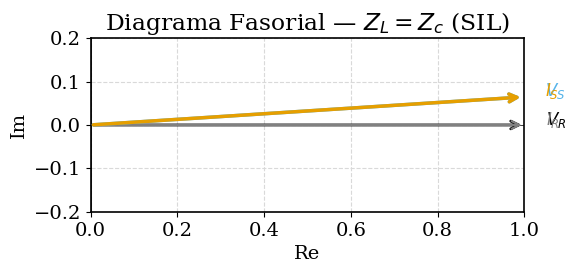

In [6]:
# Corrente no receptor: ZL = Zc
Ir = Vr / Zc

# Propagação pelo quadripolo ABCD: [Vs; Is] = Q . [Vr; Ir]
Vs, Is = Q @ np.array([Vr, Ir])

# Tensão no emissor em pu (linha-linha)
Vs_pu_mag   = abs(Vs * np.sqrt(3) / Vb)
Vs_pu_angle = np.angle(Vs * np.sqrt(3) / Vb) * 180 / np.pi

print("=== Carregamento igual a Zc ===")
print(f"  |Vs| em pu                          : {Vs_pu_mag:.6f}")
print(f"  Ângulo da tensão no emissor (°)     : {Vs_pu_angle:.4f}")
print(f"  |Is/Ir| em pu                       : {abs(Is/Ir):.6f}")
print(f"  Potência ativa no emissor (3φ) [MW] : {(3 * Vs * np.conj(Is)).real/1e6:.4f}")

phasor_diagram(Vs, Is, Vr, Ir, Vb,
               title=r"Diagrama Fasorial — $Z_L = Z_c$ (SIL)")

Qual o comprimento elétrico desse circuito?

---
## Carregamento acima de $Z_c$  ($Z_L = 2\,Z_c$)

Carga resistiva maior que a SIL: $I_R = V_R / (2\,Z_c)$.

=== Carregamento acima de Zc (ZL = 2 Zc) ===
  |Vs| em pu                          : 0.998436
  Ângulo da tensão no emissor (°)     : 1.8523
  |Is/Ir| em pu                       : 1.006230
  Potência ativa no emissor (3φ) [MW] : 25.4149


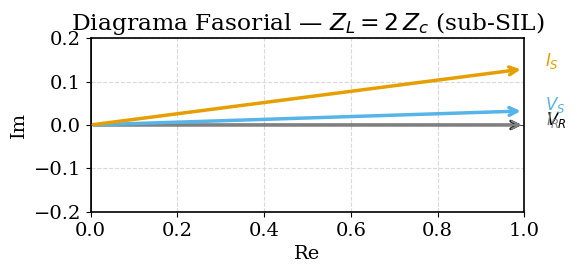

In [7]:
# Corrente no receptor: ZL = 2 Zc  (metade da corrente SIL)
Ir = Vr / (2 * Zc)

Vs, Is = Q @ np.array([Vr, Ir])

Vs_pu_mag   = abs(Vs * np.sqrt(3) / Vb)
Vs_pu_angle = np.angle(Vs * np.sqrt(3) / Vb) * 180 / np.pi

print("=== Carregamento acima de Zc (ZL = 2 Zc) ===")
print(f"  |Vs| em pu                          : {Vs_pu_mag:.6f}")
print(f"  Ângulo da tensão no emissor (°)     : {Vs_pu_angle:.4f}")
print(f"  |Is/Ir| em pu                       : {abs(Is/Ir):.6f}")
print(f"  Potência ativa no emissor (3φ) [MW] : {(3 * Vs * np.conj(Is)).real/1e6:.4f}")

phasor_diagram(Vs, Is, Vr, Ir, Vb,
               title=r"Diagrama Fasorial — $Z_L = 2\,Z_c$ (sub-SIL)")

---
## Carregamento abaixo de $Z_c$  ($Z_L = Z_c/2$)

Carga resistiva menor que a SIL: $I_R = V_R / (Z_c/2) = 2\,V_R/Z_c$.

=== Carregamento abaixo de Zc (ZL = Zc/2) ===
  |Vs| em pu                          : 1.006230
  Ângulo da tensão no emissor (°)     : 7.3710
  |Is/Ir| em pu                       : 0.998436
  Potência ativa no emissor (3φ) [MW] : 101.6598


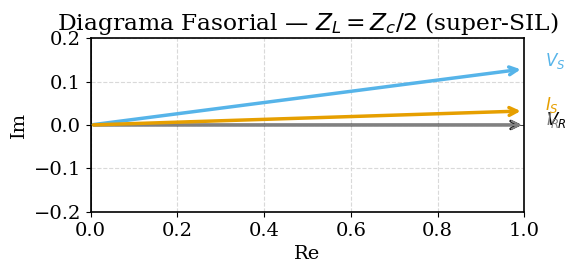

In [8]:
# Corrente no receptor: ZL = Zc/2  (dobro da corrente SIL)
Ir = Vr / (Zc / 2)

Vs, Is = Q @ np.array([Vr, Ir])

Vs_pu_mag   = abs(Vs * np.sqrt(3) / Vb)
Vs_pu_angle = np.angle(Vs * np.sqrt(3) / Vb) * 180 / np.pi

print("=== Carregamento abaixo de Zc (ZL = Zc/2) ===")
print(f"  |Vs| em pu                          : {Vs_pu_mag:.6f}")
print(f"  Ângulo da tensão no emissor (°)     : {Vs_pu_angle:.4f}")
print(f"  |Is/Ir| em pu                       : {abs(Is/Ir):.6f}")
print(f"  Potência ativa no emissor (3φ) [MW] : {(3 * Vs * np.conj(Is)).real/1e6:.4f}")

phasor_diagram(Vs, Is, Vr, Ir, Vb,
               title=r"Diagrama Fasorial — $Z_L = Z_c/2$ (super-SIL)")

---
## Resumo Comparativo

In [9]:
cases = [
    ("ZL = Zc  (SIL)",    Vr / Zc),
    ("ZL = 2Zc (sub-SIL)", Vr / (2 * Zc)),
    ("ZL = Zc/2 (super-SIL)", Vr / (Zc / 2)),
]

print(f"{'Caso':<25} {'|Vs| (pu)':>10} {'∠Vs (°)':>10} {'|Is/Ir|':>10} {'Ps (MW)':>12}")
print("-" * 72)
for name, Ir_case in cases:
    Vs_c, Is_c = Q @ np.array([Vr, Ir_case])
    Vs_pu  = abs(Vs_c * np.sqrt(3) / Vb)
    ang    = np.angle(Vs_c * np.sqrt(3) / Vb) * 180 / np.pi
    IsIr   = abs(Is_c / Ir_case)
    Ps_MW  = (3 * Vs_c * np.conj(Is_c)).real / 1e6
    print(f"{name:<25} {Vs_pu:>10.6f} {ang:>10.4f} {IsIr:>10.6f} {Ps_MW:>12.4f}")

Caso                       |Vs| (pu)    ∠Vs (°)    |Is/Ir|      Ps (MW)
------------------------------------------------------------------------
ZL = Zc  (SIL)              1.000000     3.7008   1.000000      50.8299
ZL = 2Zc (sub-SIL)          0.998436     1.8523   1.006230      25.4149
ZL = Zc/2 (super-SIL)       1.006230     7.3710   0.998436     101.6598
